# Eniac A/B Test — Button Design & Copy Analysis

| Version | Colour | Copy |
|---------|--------|------|
| A | White | SHOP NOW |
| B | Red | SHOP NOW |
| C | White | SEE DEALS |
| D | Red | SEE DEALS |

**Test period:** November 2 – 16, 2021  
**Primary metric:** Click-Through Rate (CTR)  
**Significance threshold:** α = 0.05

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [2]:
#READING THE CSV FILES
version_a_dt = pd.read_csv("eniac_a.csv")
version_b_dt = pd.read_csv("eniac_b.csv")
version_c_dt = pd.read_csv("eniac_c.csv")
version_d_dt = pd.read_csv("eniac_d.csv")

In [3]:
#CREATING COPIES I CAN WORK ON
version_a = version_a_dt.copy()
version_b = version_b_dt.copy()
version_c = version_c_dt.copy()
version_d = version_d_dt.copy()

## 1. EXPLORATION OF THE DATASETS

### 1.1 Version A — White SHOP NOW

In [4]:
#JUST EXPLORING
version_a

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN
5,36,a,Chargers & Cables,1261,False,NaN
6,99,a,iPhone Accessories,1226,False,NaN
7,68,a,Watch Accessories,1261,False,NaN
8,13,a,Mac Accessories,1308,False,NaN
9,15,a,AirTag,206,False,NaN


In [5]:
version_a.info()
#6 COLUMNS: ELEMENT ID, TAG NAME, NAME, NO. CLICKS, VISIBLE?, SNAPSHOT INFORMATION
#NO NULL VALUES EXCEPT IN SNAPSHOT INFORMATION — ONLY 2 ROWS HOLD METADATA, THAT IS EXPECTED

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Element ID            57 non-null     int64 
 1   Tag name              57 non-null     object
 2   Name                  57 non-null     object
 3   No. clicks            57 non-null     int64 
 4   Visible?              57 non-null     bool  
 5   Snapshot information  2 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 2.4+ KB


In [6]:
#TOTAL VISITS ARE IN THE METADATA STRING — READING IT MANUALLY
visits_a = 25326
print(visits_a)

25326


In [7]:
#FINDING THE BUTTON ROW
version_a.loc[version_a["Name"] == "SHOP NOW"]

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,106,a,SHOP NOW,512,True,NaN


In [8]:
#BUTTON CLICKS FOR VERSION A
clicks_a = version_a.loc[version_a["Name"] == "SHOP NOW", "No. clicks"].values[0]
print(clicks_a)

512


In [9]:
#CTR FOR VERSION A
ctr_a = clicks_a / visits_a
print(round(ctr_a * 100, 2), "%")

2.02 %


### 1.2 Version B — Red SHOP NOW

In [10]:
version_b

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,236,True,Homepage Version B - red SHOP NOW • https:...
1,25,div,mySidebar,304,True,created 2021-10-27 • 14 days 0 hours 34 mi...
2,4,a,Mac,268,True,NaN
3,69,a,iPhone,260,True,NaN
4,105,a,Accessories,1214,True,NaN
5,36,a,Chargers & Cables,1259,False,NaN
6,99,a,iPhone Accessories,1237,False,NaN
7,68,a,Watch Accessories,1221,False,NaN
8,13,a,Mac Accessories,1210,False,NaN
9,15,a,AirTag,195,False,NaN


In [11]:
#LOOKING AT THE SNAPSHOT INFORMATION TO FIND TOTAL VISITS
version_b["Snapshot information"].dropna()

0    Homepage Version B - red SHOP NOW   •   https:...
1    created 2021-10-27   •   14 days 0 hours 34 mi...
Name: Snapshot information, dtype: object

In [12]:
visits_b = 24747
print(visits_b)

24747


In [13]:
clicks_b = version_b.loc[version_b["Name"] == "SHOP NOW", "No. clicks"].values[0]
print(clicks_b)

281


In [14]:
ctr_b = clicks_b / visits_b
print(round(ctr_b * 100, 2), "%")

1.14 %


### 1.3 Version C — White SEE DEALS

In [15]:
version_c

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,288,True,Homepage Version C - white SEE DEALS • htt...
1,25,div,mySidebar,283,True,created 2021-10-27 • 14 days 0 hours 34 mi...
2,4,a,Mac,262,True,NaN
3,69,a,iPhone,234,True,NaN
4,105,a,Accessories,1288,True,NaN
5,36,a,Chargers & Cables,1224,False,NaN
6,99,a,iPhone Accessories,1175,False,NaN
7,68,a,Watch Accessories,1264,False,NaN
8,13,a,Mac Accessories,1203,False,NaN
9,15,a,AirTag,202,False,NaN


In [16]:
#LOOKING AT THE SNAPSHOT INFORMATION TO FIND TOTAL VISITS
version_c["Snapshot information"].dropna()

0    Homepage Version C - white SEE DEALS   •   htt...
1    created 2021-10-27   •   14 days 0 hours 34 mi...
Name: Snapshot information, dtype: object

In [17]:
visits_c = 24876
print(visits_c)

24876


In [18]:
#NOTE: THE BUTTON IS NOW CALLED "SEE DEALS" NOT "SHOP NOW"
clicks_c = version_c.loc[version_c["Name"] == "SEE DEALS", "No. clicks"].values[0]
print(clicks_c)

527


In [19]:
ctr_c = clicks_c / visits_c
print(round(ctr_c * 100, 2), "%")

2.12 %


### 1.4 Version D — Red SEE DEALS

In [20]:
version_d

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,285,True,Homepage Version D - red SEE DEALS • https...
1,25,div,mySidebar,305,True,created 2021-10-27 • 14 days 0 hours 34 mi...
2,4,a,Mac,274,True,NaN
3,69,a,iPhone,243,True,NaN
4,105,a,Accessories,1267,True,NaN
5,36,a,Chargers & Cables,1260,False,NaN
6,99,a,iPhone Accessories,1296,False,NaN
7,68,a,Watch Accessories,1252,False,NaN
8,13,a,Mac Accessories,1273,False,NaN
9,15,a,AirTag,201,False,NaN


In [21]:
#LOOKING AT THE SNAPSHOT INFORMATION TO FIND TOTAL VISITS
version_d["Snapshot information"].dropna()

0    Homepage Version D - red SEE DEALS   •   https...
1    created 2021-10-27   •   14 days 0 hours 34 mi...
Name: Snapshot information, dtype: object

In [22]:
visits_d = 25233
print(visits_d)

25233


In [23]:
clicks_d = version_d.loc[version_d["Name"] == "SEE DEALS", "No. clicks"].values[0]
print(clicks_d)

193


In [24]:
ctr_d = clicks_d / visits_d
print(round(ctr_d * 100, 2), "%")

0.76 %


## 2. SUMMARY TABLE

In [25]:
#BUILDING A SUMMARY TABLE FOR ALL FOUR VERSIONS
summary = pd.DataFrame({
    "Version":       ["A", "B", "C", "D"],
    "Button":        ["White SHOP NOW", "Red SHOP NOW", "White SEE DEALS", "Red SEE DEALS"],
    "Visits":        [visits_a, visits_b, visits_c, visits_d],
    "Button Clicks": [clicks_a, clicks_b, clicks_c, clicks_d],
    "No-Clicks":     [visits_a - clicks_a, visits_b - clicks_b,
                      visits_c - clicks_c, visits_d - clicks_d],
    "CTR (%)": [round(ctr_a*100,2), round(ctr_b*100,2),
                round(ctr_c*100,2), round(ctr_d*100,2)],
})

summary

,Version,Button,Visits,Button Clicks,No-Clicks,CTR (%)
0,A,White SHOP NOW,25326,512,24814,2.02
1,B,Red SHOP NOW,24747,281,24466,1.14
2,C,White SEE DEALS,24876,527,24349,2.12
3,D,Red SEE DEALS,25233,193,25040,0.76


In [26]:
#VERSION C HAS THE HIGHEST CTR AT 2.12%
#VERSION D HAS THE LOWEST CTR AT 0.76% — ALMOST 3X WORSE THAN C
#WHITE BUTTONS CLEARLY OUTPERFORM RED BUTTONS
#ALL VERSIONS RECEIVED A SIMILAR NUMBER OF VISITS — TRAFFIC WAS SPLIT EVENLY

## 3. VISUALISING THE CTR

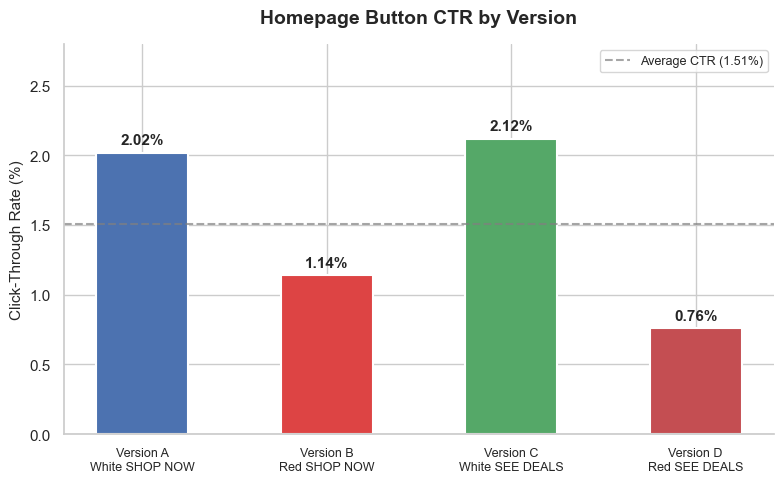

In [27]:
sns.set_theme(style="whitegrid")

bar_colours = ["#4C72B0", "#DD4444", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    summary["Version"],
    summary["CTR (%)"],
    color=bar_colours,
    width=0.5,
    edgecolor="white",
    linewidth=1.5
)

for bar, ctr in zip(bars, summary["CTR (%)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f"{ctr:.2f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_xticks(range(4))
ax.set_xticklabels(
    [f"Version {v}\n{b}" for v, b in zip(summary["Version"], summary["Button"])],
    fontsize=9
)
ax.set_ylabel("Click-Through Rate (%)", fontsize=11)
ax.set_title("Homepage Button CTR by Version", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, 2.8)
ax.axhline(summary["CTR (%)"].mean(), color="grey", linestyle="--", alpha=0.7,
           label=f"Average CTR ({summary['CTR (%)'].mean():.2f}%)")
ax.legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig("ctr_by_version.png", bbox_inches="tight")
plt.show()

## 4. CHI-SQUARE TEST

**H₀:** All versions have the same CTR — differences are due to chance.  
**H₁:** At least one version has a significantly different CTR.  
**α = 0.05**

In [28]:
#BUILDING THE CONTINGENCY TABLE
#ROWS = VERSIONS, COLUMNS = [CLICKS, NO-CLICKS]
contingency_table = np.array([
    [clicks_a, visits_a - clicks_a],
    [clicks_b, visits_b - clicks_b],
    [clicks_c, visits_c - clicks_c],
    [clicks_d, visits_d - clicks_d],
])

ct_df = pd.DataFrame(
    contingency_table,
    index=["Version A", "Version B", "Version C", "Version D"],
    columns=["Click", "No-Click"]
)
ct_df

,Click,No-Click
Version A,512,24814
Version B,281,24466
Version C,527,24349
Version D,193,25040


In [29]:
#RUNNING THE OVERALL CHI-SQUARE TEST
chisq, pvalue, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic : {chisq:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {pvalue:.2e}")

Chi-square statistic : 224.0188
Degrees of freedom   : 3
p-value              : 2.72e-48


In [30]:
pvalue < 0.05
#TRUE — WE REJECT H0
#THE DIFFERENCES IN CTR ARE STATISTICALLY SIGNIFICANT, NOT DUE TO CHANCE

np.True_

## 5. POST-HOC TESTS — BONFERRONI CORRECTION

THE OVERALL TEST TELLS US *SOME* VERSION IS DIFFERENT — NOT WHICH ONES.  
WE RUN PAIRWISE CHI-SQUARE TESTS AND DIVIDE ALPHA BY THE NUMBER OF PAIRS TO AVOID FALSE POSITIVES.

$$\alpha_{adjusted} = \frac{0.05}{6 \text{ pairs}} = 0.0083$$

In [31]:
#BONFERRONI ADJUSTED ALPHA — 6 POSSIBLE PAIRS FROM 4 VERSIONS
alpha_bonferroni = 0.05 / 6
print(round(alpha_bonferroni, 4))

0.0083


In [32]:
#A vs B
ct_ab = np.array([
    [clicks_a, visits_a - clicks_a],
    [clicks_b, visits_b - clicks_b]
])
chisq_ab, pvalue_ab, _, _ = stats.chi2_contingency(ct_ab)
print(f"A vs B — chi2: {chisq_ab:.4f} | p: {pvalue_ab:.2e} | Significant: {pvalue_ab < alpha_bonferroni}")

A vs B — chi2: 62.4936 | p: 2.67e-15 | Significant: True


In [33]:
#A vs C
ct_ac = np.array([
    [clicks_a, visits_a - clicks_a],
    [clicks_c, visits_c - clicks_c]
])
chisq_ac, pvalue_ac, _, _ = stats.chi2_contingency(ct_ac)
print(f"A vs C — chi2: {chisq_ac:.4f} | p: {pvalue_ac:.2e} | Significant: {pvalue_ac < alpha_bonferroni}")
#NOT SIGNIFICANT — A AND C CANNOT BE SEPARATED ON CTR ALONE
#WE NEED SECONDARY METRICS TO PICK A WINNER

A vs C — chi2: 0.5342 | p: 4.65e-01 | Significant: False


In [34]:
#A vs D
ct_ad = np.array([
    [clicks_a, visits_a - clicks_a],
    [clicks_d, visits_d - clicks_d]
])
chisq_ad, pvalue_ad, _, _ = stats.chi2_contingency(ct_ad)
print(f"A vs D — chi2: {chisq_ad:.4f} | p: {pvalue_ad:.2e} | Significant: {pvalue_ad < alpha_bonferroni}")

A vs D — chi2: 144.2832 | p: 3.08e-33 | Significant: True


In [35]:
#B vs C
ct_bc = np.array([
    [clicks_b, visits_b - clicks_b],
    [clicks_c, visits_c - clicks_c]
])
chisq_bc, pvalue_bc, _, _ = stats.chi2_contingency(ct_bc)
print(f"B vs C — chi2: {chisq_bc:.4f} | p: {pvalue_bc:.2e} | Significant: {pvalue_bc < alpha_bonferroni}")

B vs C — chi2: 74.2292 | p: 6.96e-18 | Significant: True


In [36]:
#B vs D
ct_bd = np.array([
    [clicks_b, visits_b - clicks_b],
    [clicks_d, visits_d - clicks_d]
])
chisq_bd, pvalue_bd, _, _ = stats.chi2_contingency(ct_bd)
print(f"B vs D — chi2: {chisq_bd:.4f} | p: {pvalue_bd:.2e} | Significant: {pvalue_bd < alpha_bonferroni}")

B vs D — chi2: 17.8763 | p: 2.36e-05 | Significant: True


In [37]:
#C vs D
ct_cd = np.array([
    [clicks_c, visits_c - clicks_c],
    [clicks_d, visits_d - clicks_d]
])
chisq_cd, pvalue_cd, _, _ = stats.chi2_contingency(ct_cd)
print(f"C vs D — chi2: {chisq_cd:.4f} | p: {pvalue_cd:.2e} | Significant: {pvalue_cd < alpha_bonferroni}")

C vs D — chi2: 161.1170 | p: 6.45e-37 | Significant: True


In [38]:
#SUMMARY OF ALL POST-HOC RESULTS
posthoc = pd.DataFrame({
    "Pair":        ["A vs B", "A vs C", "A vs D", "B vs C", "B vs D", "C vs D"],
    "Chi2":        [chisq_ab, chisq_ac, chisq_ad, chisq_bc, chisq_bd, chisq_cd],
    "p-value":     [pvalue_ab, pvalue_ac, pvalue_ad, pvalue_bc, pvalue_bd, pvalue_cd],
    "Significant": [
        pvalue_ab < alpha_bonferroni,
        pvalue_ac < alpha_bonferroni,
        pvalue_ad < alpha_bonferroni,
        pvalue_bc < alpha_bonferroni,
        pvalue_bd < alpha_bonferroni,
        pvalue_cd < alpha_bonferroni,
    ]
})

posthoc
#A vs C IS THE ONLY NON-SIGNIFICANT PAIR
#ALL OTHER PAIRS SHOW REAL DIFFERENCES — NOT DUE TO CHANCE

,Pair,Chi2,p-value,Significant
0,A vs B,62.493623,2.673088e-15,True
1,A vs C,0.534210,4.648421e-01,False
2,A vs D,144.283184,3.080898e-33,True
3,B vs C,74.229172,6.955480e-18,True
4,B vs D,17.876340,2.357337e-05,True
5,C vs D,161.117041,6.450501e-37,True


C:\Users\abssi\AppData\Local\Temp\ipykernel_8544\2117543192.py:19: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\abssi\AppData\Local\Temp\ipykernel_8544\2117543192.py:19: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\abssi\AppData\Local\Temp\ipykernel_8544\2117543192.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("posthoc_pvalues.png", bbox_inches="tight")
C:\Users\abssi\AppData\Local\Temp\ipykernel_8544\2117543192.py:20: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("posthoc_pvalues.png", bbox_inches="tight")
c:\Users\abssi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\abssi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8

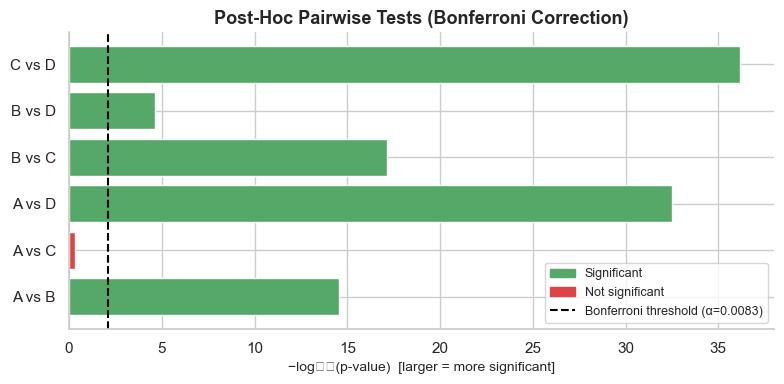

In [39]:
#VISUALISING POST-HOC P-VALUES ON A LOG SCALE
bar_cols = ["#55A868" if s else "#DD4444" for s in posthoc["Significant"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(posthoc["Pair"], -np.log10(posthoc["p-value"]),
        color=bar_cols, edgecolor="white", linewidth=1)
ax.axvline(-np.log10(alpha_bonferroni), color="black", linestyle="--",
           linewidth=1.5)

green_patch = mpatches.Patch(color="#55A868", label="Significant")
red_patch   = mpatches.Patch(color="#DD4444", label="Not significant")
threshold_line = plt.Line2D([0],[0], color="black", linestyle="--",
                             label=f"Bonferroni threshold (α={alpha_bonferroni:.4f})")
ax.legend(handles=[green_patch, red_patch, threshold_line], fontsize=9)

ax.set_xlabel("−log₁₀(p-value)  [larger = more significant]", fontsize=10)
ax.set_title("Post-Hoc Pairwise Tests (Bonferroni Correction)", fontsize=13, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("posthoc_pvalues.png", bbox_inches="tight")
plt.show()

## 6. SECONDARY METRICS

SINCE A AND C CANNOT BE SEPARATED ON CTR, WE LOOK AT TWO ADDITIONAL METRICS:
- **DROP-OFF RATE** — % of users who start but don't complete a purchase (lower is better)
- **HOMEPAGE-RETURN RATE** — % of users who go back to the homepage after clicking (lower is better)

NOTE: VERSION B SECONDARY DATA WAS LOST DUE TO A DATA COLLECTION ERROR

In [40]:
#SECONDARY METRICS TABLE — VALUES FROM THE EXPERIMENT REPORT
secondary = pd.DataFrame({
    "Version":                  ["A", "C", "D"],
    "Button":                   ["White SHOP NOW", "White SEE DEALS", "Red SEE DEALS"],
    "Drop-off Rate (%)": [78.0, 67.0, 71.0],
    "Homepage-Return Rate (%)": [45.0, 39.0, 46.0],
})

secondary

,Version,Button,Drop-off Rate (%),Homepage-Return Rate (%)
0,A,White SHOP NOW,78.0,45.0
1,C,White SEE DEALS,67.0,39.0
2,D,Red SEE DEALS,71.0,46.0


In [41]:
#VERSION C HAS THE LOWEST DROP-OFF RATE: 67% vs 78% FOR VERSION A
#VERSION C HAS THE LOWEST HOMEPAGE-RETURN RATE: 39% vs 45% FOR VERSION A
#USERS WHO CLICK "SEE DEALS" ARE MORE ENGAGED AND FIND WHAT THEY NEED MORE RELIABLY

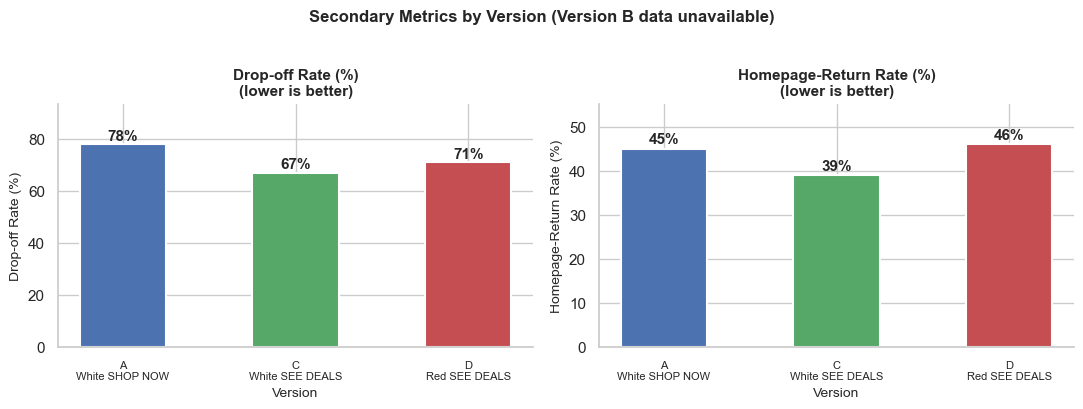

In [42]:
#VISUALISING SECONDARY METRICS
bar_cols_sec = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["Drop-off Rate (%)", "Homepage-Return Rate (%)"]):
    bars = ax.bar(secondary["Version"], secondary[col],
                  color=bar_cols_sec, width=0.5, edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, secondary[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_xlabel("Version", fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(col + "\n(lower is better)", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(secondary[col]) * 1.2)
    ax.set_xticks(range(3))
    ax.set_xticklabels(
        [f"{v}\n{b}" for v, b in zip(secondary["Version"], secondary["Button"])],
        fontsize=8
    )

plt.suptitle("Secondary Metrics by Version (Version B data unavailable)",
             fontsize=12, fontweight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig("secondary_metrics.png", bbox_inches="tight")
plt.show()

## 7. FINAL RECOMMENDATION

In [43]:
#FINAL SCORECARD — COMPARING THE TWO FINALISTS
scorecard = pd.DataFrame({
    "Version":             ["A", "C"],
    "Button":              ["White SHOP NOW", "White SEE DEALS"],
    "CTR (%)": [2.02, 2.12],
    "Drop-off (%)": [78, 67],
    "Homepage-Return (%)": [45, 39],
})

scorecard

,Version,Button,CTR (%),Drop-off (%),Homepage-Return (%)
0,A,White SHOP NOW,2.02,78,45
1,C,White SEE DEALS,2.12,67,39


In [44]:
#WINNER: VERSION C — WHITE "SEE DEALS" BUTTON

#REASONS:
#1. HIGHEST CTR AT 2.12% — STATISTICALLY TIED WITH A BUT NUMERICALLY HIGHER
#2. LOWEST DROP-OFF RATE AT 67% — 11 PERCENTAGE POINTS BETTER THAN A (78%)
#   USERS WHO CLICK ARE MORE LIKELY TO COMPLETE A PURCHASE
#3. LOWEST HOMEPAGE-RETURN RATE AT 39% — USERS FIND WHAT THEY NEED MORE RELIABLY
#4. USER SURVEY FEEDBACK: "SHOP NOW" FELT TOO PUSHY AND PRESUMPTUOUS
#   "SEE DEALS" LOWERS THE PERCEIVED COMMITMENT AND ATTRACTS MORE INTENTIONAL CLICKS

#COLOUR CONCLUSION:
#WHITE BUTTONS RECEIVED ROUGHLY 2X MORE CLICKS THAN RED IN BOTH COPY VARIANTS
#RED SHOULD NOT BE USED FOR THIS BUTTON